# SU2 bosonic model, $\Lambda = 4$: Final Results

Notebook created by HLD for the work arXiv: 2503.13368 [quant-ph, hep-th]

In this notebook, we process the final results for the VQE experiments for bosonic SU(2) matrix model at $\Lambda = 4$ using different variants of EvolvedOperatorAnsatz.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

E_02 = 3.13406
E_05 = 3.29894
E_10 = 3.52625
E_20 = 3.89548

In [2]:
def load_drop(link, drop = False):
    df = pd.read_csv(link)
    if drop:
        df.drop(['Unnamed: 0', 'ev_op_H40', 'ev_op_Hp40_2f'], axis = 1, inplace=True)
    else:
        df.drop(['Unnamed: 0'], axis = 1, inplace=True)
    return df

In [3]:
def plot_e(df, ax, Ee):
    ax.axhline(Ee, color = 'black', linestyle = 'dashed', label = 'Exact energy')
    for i in range(len(df.columns)):
        ax.plot(np.arange(len(df[df.columns[i]])),df[df.columns[i]],color = color_list[i], 
                 label=df.columns[i])
    ax.legend()
    ax.set_xlabel('Iterations', fontsize = 13)
    ax.set_ylabel('Energy', fontsize = 13)
    
def find_best_ansatz(df, Ee):
    c_i = np.argmin(np.abs(df['cobyla_values']- Ee))
    print(f'Exact energy is {Ee}')
    print(f'Best ansatz for COBYLA is {df.index[c_i]} with value: {df.cobyla_values[c_i]}')
    s_i = np.argmin(np.abs(df['spsa_values']- Ee))
    print(f'Best ansatz for SPSA is {df.index[s_i]} with value: {df.spsa_values[s_i]}')
    diff_c = np.abs(df.cobyla_values[c_i]-Ee)
    diff_s = np.abs(df.spsa_values[s_i]-Ee)
    if diff_c < diff_s:
        print(f'Best ansatz overall is {df.index[c_i]}')
    if diff_c > diff_s:
         print(f'Best ansatz overall is {df.index[s_i]}')

 # Load data and plot convergence curves

In [7]:
df_02_c = load_drop('results/l_02_cobyla_curves_values.csv')
df_02_s = load_drop('results/l_02_spsa_curves_values.csv')

df_05_c = load_drop('results/l_05_cobyla_curves_values.csv')
df_05_s = load_drop('results/l_05_spsa_curves_values.csv')

df_10_c =load_drop('results/l_10_cobyla_curves_values.csv')
df_10_s =load_drop('results/l_10_spsa_curves_values.csv')

df_20_c =load_drop('results/l_20_cobyla_curves_values.csv')
df_20_s =load_drop('results/l_20_spsa_curves_values.csv')

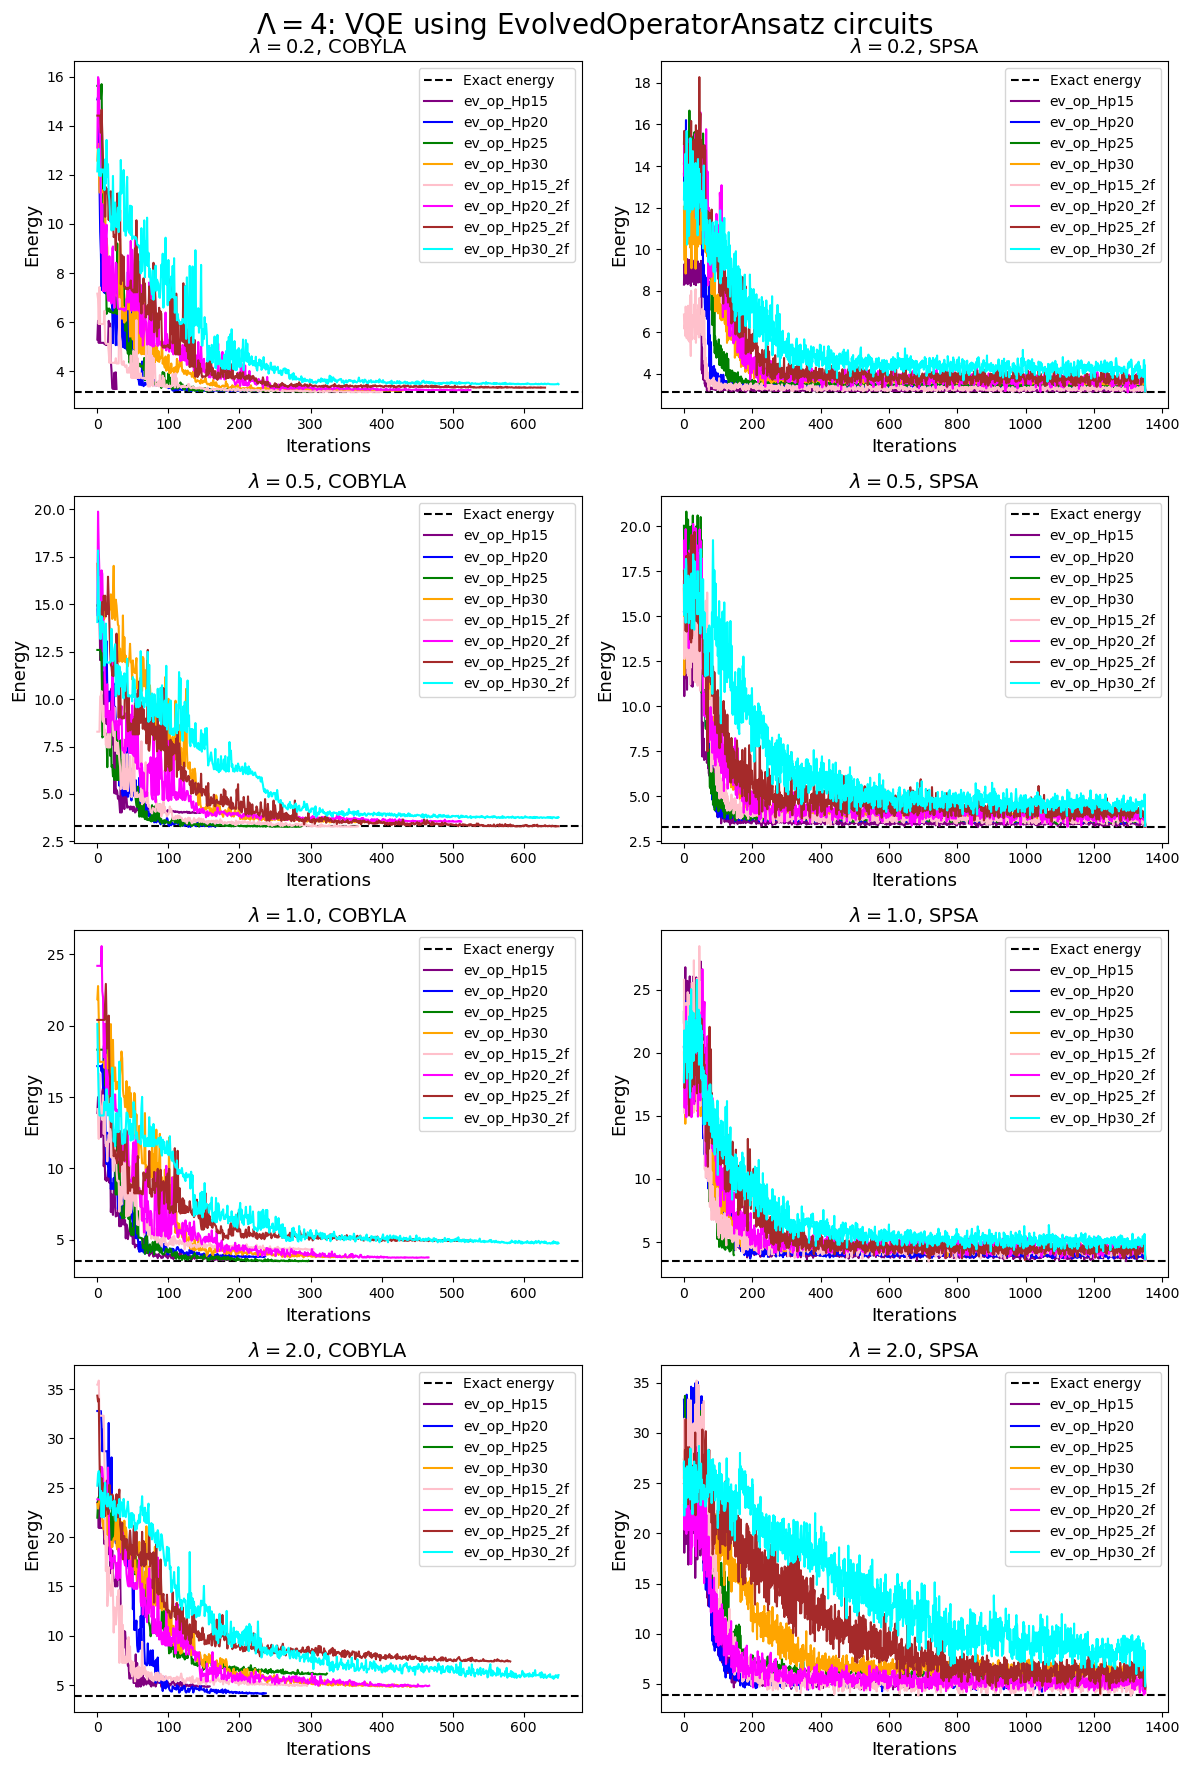

In [9]:
fig, ax = plt.subplots(4,2, figsize=(12,18), tight_layout = True)
color_list = ['purple', 'blue', 'green', 'orange', 'pink', 'magenta', 'brown','cyan', 'yellow']
###################################
plot_e(df_02_c, ax[0,0], E_02)
ax[0,0].set_title('$\lambda=0.2$, COBYLA',fontsize = 14)

plot_e(df_02_s, ax[0,1], E_02)
ax[0,1].set_title('$\lambda=0.2$, SPSA',fontsize = 14)
###################################
plot_e(df_05_c, ax[1,0], E_05)
ax[1,0].set_title('$\lambda=0.5$, COBYLA',fontsize = 14)

plot_e(df_05_s, ax[1,1], E_05)
ax[1,1].set_title('$\lambda=0.5$, SPSA',fontsize = 14)
###################################
plot_e(df_10_c, ax[2,0], E_10)
ax[2,0].set_title('$\lambda=1.0$, COBYLA',fontsize = 14)

plot_e(df_10_s, ax[2,1], E_10)
ax[2,1].set_title('$\lambda=1.0$, SPSA',fontsize = 14)
###################################
plot_e(df_20_c, ax[3,0], E_20)
ax[3,0].set_title('$\lambda=2.0$, COBYLA',fontsize = 14)

plot_e(df_20_s, ax[3,1], E_20)
ax[3,1].set_title('$\lambda=2.0$, SPSA',fontsize = 14)

plt.suptitle('$\Lambda=4$: VQE using EvolvedOperatorAnsatz circuits', fontsize = 20)
plt.savefig('results/L=4_ev_op_convergence_curves.png')

# Check best ansatzes

In [11]:
df_l02 = pd.read_csv('results/l0.2_last_val_best.csv')
df_l05 = pd.read_csv('results/l0.5_last_val_best.csv')
df_l10 = pd.read_csv('results/l1.0_last_val_best.csv')
df_l20 = pd.read_csv('results/l2.0_last_val_best.csv')

df_l02.set_index('name', inplace = True)
df_l05.set_index('name', inplace = True)
df_l10.set_index('name', inplace = True)
df_l20.set_index('name', inplace = True)

In [13]:
def find_best_ansatz(df, Ee):
    c_i = np.argmin(np.abs(df['cobyla_values']- Ee))
    print(f'Exact energy is {Ee}')
    print(f'Best ansatz for COBYLA is {df.index[c_i]} with value: {df.cobyla_values[c_i]}')
    s_i = np.argmin(np.abs(df['spsa_values']- Ee))
    print(f'Best ansatz for SPSA is {df.index[s_i]} with value: {df.spsa_values[s_i]}')
    diff_c = np.abs(df.cobyla_values[c_i]-Ee)
    diff_s = np.abs(df.spsa_values[s_i]-Ee)
    if diff_c < diff_s:
        print(f'Best ansatz overall is {df.index[c_i]}')
    if diff_c > diff_s:
         print(f'Best ansatz overall is {df.index[s_i]}')

In [15]:
find_best_ansatz(df_l02, E_02)

Exact energy is 3.13406
Best ansatz for COBYLA is ev_op_Hp15_2f with value: 3.15952
Best ansatz for SPSA is ev_op_Hp25_2f with value: 3.13421
Best ansatz overall is ev_op_Hp25_2f


In [17]:
df_l02

,cobyla_values,spsa_values
name,,
ev_op_Hp15,3.27813,3.17320
ev_op_Hp20,3.18835,3.15612
ev_op_Hp25,3.17782,3.14337
ev_op_Hp30,3.21665,3.14084
ev_op_Hp15_2f,3.15952,3.15614
ev_op_Hp20_2f,3.23598,3.19462
ev_op_Hp25_2f,3.33135,3.13421
ev_op_Hp30_2f,3.47127,3.15462


In [19]:
find_best_ansatz(df_l05, E_05)

Exact energy is 3.29894
Best ansatz for COBYLA is ev_op_Hp25 with value: 3.29968
Best ansatz for SPSA is ev_op_Hp25_2f with value: 3.29896
Best ansatz overall is ev_op_Hp25_2f


In [21]:
df_l05

,cobyla_values,spsa_values
name,,
ev_op_Hp15,4.03464,3.41548
ev_op_Hp20,3.35601,3.30692
ev_op_Hp25,3.29968,3.42603
ev_op_Hp30,3.51242,3.30582
ev_op_Hp15_2f,3.30153,3.34375
ev_op_Hp20_2f,3.54492,3.30794
ev_op_Hp25_2f,3.30028,3.29896
ev_op_Hp30_2f,3.77042,3.33945


In [23]:
find_best_ansatz(df_l10, E_10)

Exact energy is 3.52625
Best ansatz for COBYLA is ev_op_Hp25 with value: 3.53512
Best ansatz for SPSA is ev_op_Hp30 with value: 3.54551
Best ansatz overall is ev_op_Hp25


In [25]:
df_l10

,cobyla_values,spsa_values
name,,
ev_op_Hp15,3.62082,3.67193
ev_op_Hp20,3.84073,3.60327
ev_op_Hp25,3.53512,3.96745
ev_op_Hp30,3.77387,3.54551
ev_op_Hp15_2f,4.35314,3.71765
ev_op_Hp20_2f,3.75998,3.59577
ev_op_Hp25_2f,4.92616,3.68810
ev_op_Hp30_2f,4.75916,3.63468


In [27]:
find_best_ansatz(df_l20, E_20)

Exact energy is 3.89548
Best ansatz for COBYLA is ev_op_Hp20 with value: 4.16425
Best ansatz for SPSA is ev_op_Hp15_2f with value: 3.93348
Best ansatz overall is ev_op_Hp15_2f


In [29]:
df_l20

,cobyla_values,spsa_values
name,,
ev_op_Hp15,4.86152,4.69522
ev_op_Hp20,4.16425,4.62906
ev_op_Hp25,6.16766,4.37152
ev_op_Hp30,4.88188,4.12944
ev_op_Hp15_2f,4.94432,3.93348
ev_op_Hp20_2f,4.93465,4.10240
ev_op_Hp25_2f,7.39414,4.51453
ev_op_Hp30_2f,6.01181,4.76864


# Plot comparisons

In [31]:
def plot_ax(ax, df, Ee, ll):
    ax.plot(df['cobyla_values'], color='green', marker='o', linestyle='dashed', label='cobyla')
    ax.plot(df['spsa_values'], color='purple', marker='o', linestyle='dashed', label = 'spsa')
    ax.axhline(Ee, color = 'red', label='Exact energy')
    for tick in ax.get_xticklabels():
        tick.set_rotation(90)
    ax.set_title(f'$\lambda$ = {ll}', fontsize = 18)
    ax.legend()
    ax.set_ylabel('Energy', fontsize = 15)
    ax.xaxis.grid(True)

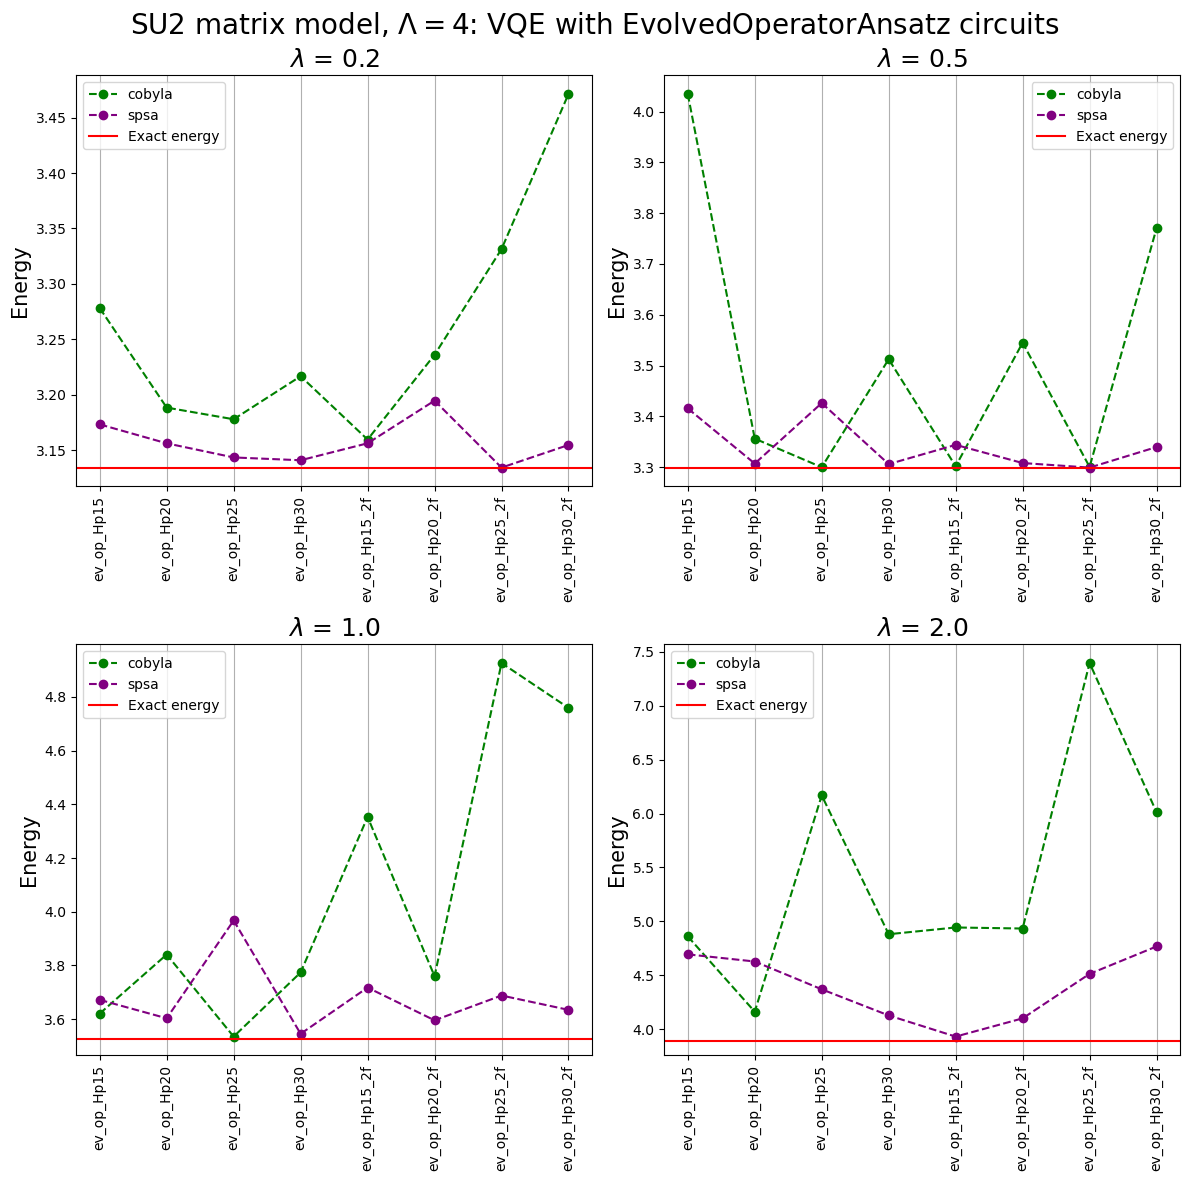

In [33]:
fig, ax = plt.subplots(2,2, figsize = (12,12), tight_layout= True)

plot_ax(ax[0,0],df_l02, E_02, 0.2)
plot_ax(ax[0,1],df_l05, E_05, 0.5)
plot_ax(ax[1,0],df_l10, E_10, 1.0)
plot_ax(ax[1,1],df_l20, E_20, 2.0)

plt.suptitle('SU2 matrix model, $\Lambda=4$: VQE with EvolvedOperatorAnsatz circuits', fontsize = 20)
plt.savefig('results/L=4_ev_op_ansatze.png')